In [7]:
import json, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

E9_DIR  = Path("runs_e9")
E14_DIR = Path("runs_e14")
FROZEN = {"D-1": dict(max_eta=0.74, r_cert=16,  e9=0.566), "M-3": dict(max_eta=0.87, r_cert=128, e9=0.068)}
ADV = {"D-1": dict(max_eta=0.00, r_cert=512), "M-3": dict(max_eta=0.76, r_cert=32)}

def load_e14():
    out = {}
    for fn in sorted(glob.glob(str(E14_DIR / "*.json"))):
        d = json.load(open(fn))
        out[d["chan"]] = dict(max_eta=max(l["max_eta"] for l in d["labels"]), r_cert=min(l["r_cert"] for l in d["labels"]))
    for c, v in FROZEN.items():
        out[c] = dict(max_eta=v["max_eta"], r_cert=v["r_cert"])
    return out

def load_e9():
    out = {}
    for fn in sorted(glob.glob(str(E9_DIR / "*.json"))):
        d = json.load(open(fn))
        rates = [cr["defended_rate_model"]
                 for lab in d["labels"] for cr in lab.get("by_config", {}).values()
                 if cr.get("defended_rate_model") is not None]
        out[d["chan"]] = max(rates) if rates else None
    for c, v in FROZEN.items():
        out[c] = v["e9"]
    return out

e14, e9 = load_e14(), load_e9()
chans = sorted(e14)
print(f"{len(chans)} channels loaded")

23 channels loaded


In [8]:
W = 66
print("=" * W); print("Section 8.5 ledger  —  Week 7"); print("=" * W)
print(f"{'criterion':<36}{'target':>11}{'achieved':>19}")
print("-" * W)
rows = [("E9 defended evasion (cells)",        "<= 5%",      "46/50"), ("  exception: D-1 (large eta_w)",     "",           "57% -> rescued"), ("E14 certified radius r_cert",        ">= 50 bits", "24/25"), ("  exception: D-1",                   "",           "16 -> 512 (adv)"), ("E12 keyed-pi per frame / LDPC",      "< 5%",       "1.2-3% (opt FY)"), ("E12 keyed-pi inference cost",        "near-free",  "0.61 ms/frame")]
for a, b, c in rows:
    print(f"{a:<36}{b:>11}{c:>19}")
print("-" * W)
print("adv-training rescues D-1 (eta_w 0.74->0.00, attack defeated, clean kept);")
print("M-3 attack defeated operationally but cert keeps the L_inf != Hamming gap.")

Section 8.5 ledger  —  Week 7
criterion                                target           achieved
------------------------------------------------------------------
E9 defended evasion (cells)               <= 5%              46/50
  exception: D-1 (large eta_w)                      57% -> rescued
E14 certified radius r_cert          >= 50 bits              24/25
  exception: D-1                                   16 -> 512 (adv)
E12 keyed-pi per frame / LDPC              < 5%    1.2-3% (opt FY)
E12 keyed-pi inference cost           near-free      0.61 ms/frame
------------------------------------------------------------------
adv-training rescues D-1 (eta_w 0.74->0.00, attack defeated, clean kept);
M-3 attack defeated operationally but cert keeps the L_inf != Hamming gap.


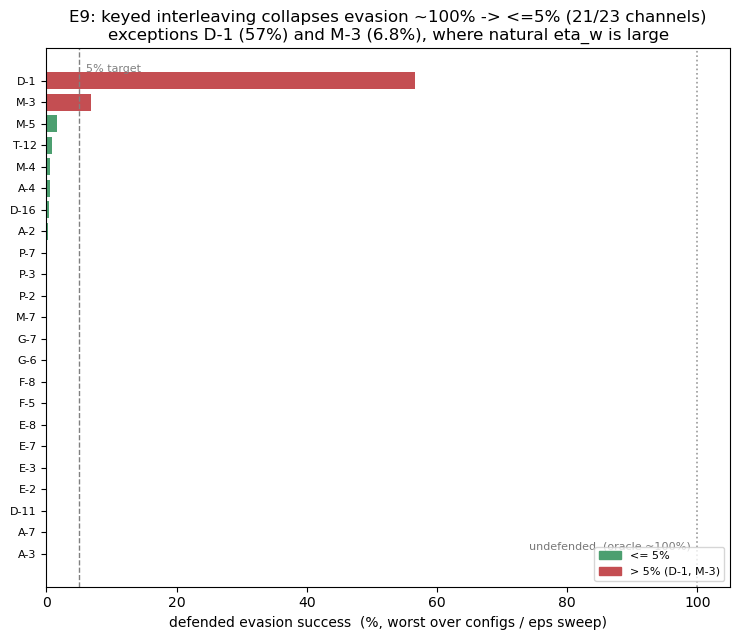

In [9]:
order = sorted(chans, key=lambda c: (e9[c] if e9[c] is not None else -1))
vals  = np.array([100 * e9[c] if e9[c] is not None else 0.0 for c in order])
cols  = ["#c44e52" if v > 5 else "#4c9f70" for v in vals]
fig, ax = plt.subplots(figsize=(7.5, 6.5)); y = np.arange(len(order))
ax.barh(y, vals, color=cols)
ax.axvline(100, color="#999", ls=":", lw=1.2)
ax.text(99, 0.2, "undefended  (oracle ~100%)", color="#777", fontsize=8, ha="right")
ax.axvline(5, color="gray", ls="--", lw=1)
ax.text(6, len(order) - 0.6, "5% target", color="gray", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8); ax.set_xlim(0, 105)
ax.set_xlabel("defended evasion success  (%, worst over configs / eps sweep)")
ax.set_title("E9: keyed interleaving collapses evasion ~100% -> <=5% (21/23 channels)\n" "exceptions D-1 (57%) and M-3 (6.8%), where natural eta_w is large")
ax.legend(handles=[Patch(color="#4c9f70", label="<= 5%"), Patch(color="#c44e52", label="> 5% (D-1, M-3)")], loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

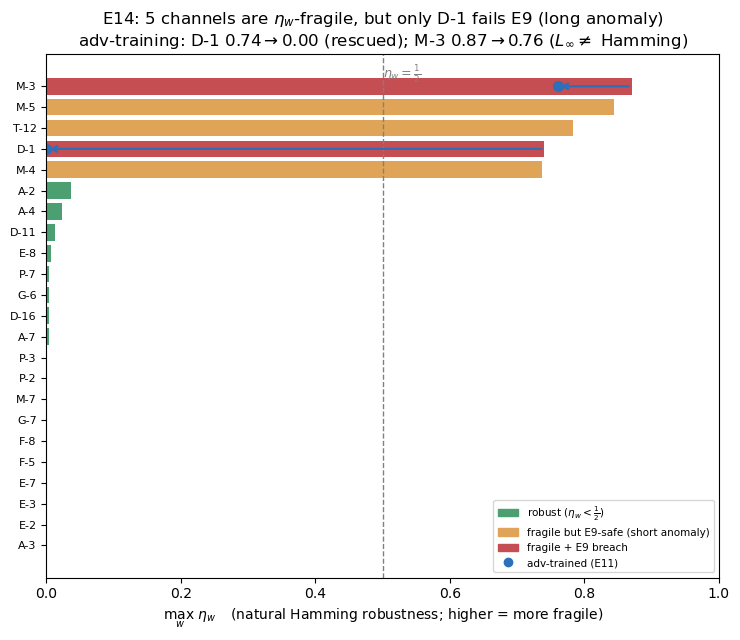

In [10]:
order = sorted(chans, key=lambda c: e14[c]["max_eta"])
me    = np.array([e14[c]["max_eta"] for c in order])
def ocolor(c):
    if e14[c]["max_eta"] < 0.5: return "#4c9f70"
    return "#c44e52" if (e9[c] or 0) > 0.05 else "#e0a458"
fig, ax = plt.subplots(figsize=(7.5, 6.5)); y = np.arange(len(order))
ax.barh(y, me, color=[ocolor(c) for c in order])
ax.axvline(0.5, color="gray", ls="--", lw=1)
ax.text(0.5, len(order) - 0.6, r"$\eta_w=\frac{1}{2}$", color="gray", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8); ax.set_xlim(0, 1)
ax.set_xlabel(r"$\max_w\ \eta_w$   (natural Hamming robustness; higher = more fragile)")
for c in ["D-1", "M-3"]:
    i = order.index(c)
    ax.annotate("", xy=(ADV[c]["max_eta"], i), xytext=(e14[c]["max_eta"], i), arrowprops=dict(arrowstyle="->", color="#2c6fbb", lw=1.6))
    ax.plot(ADV[c]["max_eta"], i, "o", color="#2c6fbb", ms=7)
ax.set_title(r"E14: 5 channels are $\eta_w$-fragile, but only D-1 fails E9 (long anomaly)" "\nadv-training: D-1 0.74$\\to$0.00 (rescued); M-3 0.87$\\to$0.76 ($L_\\infty\\neq$ Hamming)")
ax.legend(handles=[Patch(color="#4c9f70", label=r"robust ($\eta_w<\frac{1}{2}$)"), Patch(color="#e0a458", label="fragile but E9-safe (short anomaly)"), Patch(color="#c44e52", label="fragile + E9 breach"), Line2D([], [], marker="o", color="#2c6fbb", ls="", label="adv-trained (E11)")], loc="lower right", fontsize=7.5)
plt.tight_layout(); plt.show()

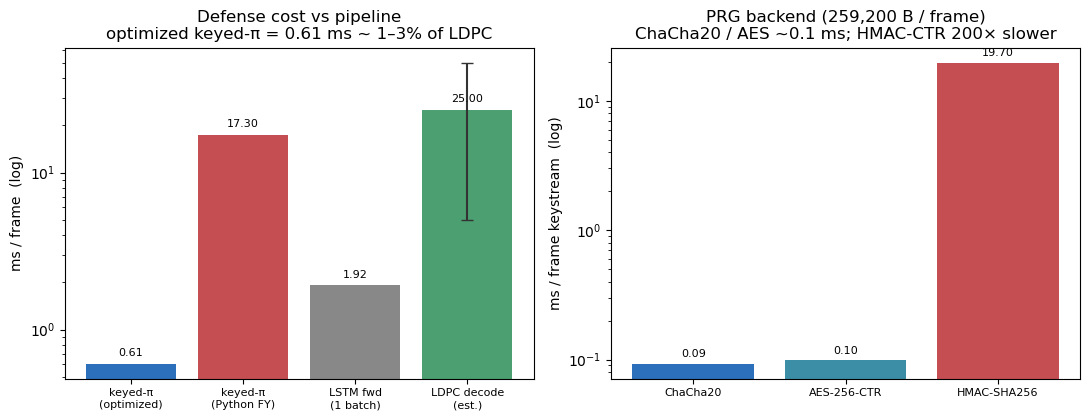

In [11]:
defense_opt, defense_proto = 0.607, 17.298
lstm, ldpc = 1.915, (5.0, 20.0, 50.0)
prg = {"ChaCha20": 0.093, "AES-256-CTR": 0.099, "HMAC-SHA256": 19.701}
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
labels = ["keyed-π\n(optimized)", "keyed-π\n(Python FY)", "LSTM fwd\n(1 batch)", "LDPC decode\n(est.)"]
vals   = [defense_opt, defense_proto, lstm, np.mean(ldpc)]
bars = ax[0].bar(labels, vals, color=["#2c6fbb", "#c44e52", "#888", "#4c9f70"])
ax[0].errorbar(3, np.mean(ldpc), yerr=[[np.mean(ldpc) - ldpc[0]], [ldpc[2] - np.mean(ldpc)]], fmt="none", ecolor="#333", capsize=4)
ax[0].set_yscale("log"); ax[0].set_ylabel("ms / frame  (log)")
ax[0].set_title("Defense cost vs pipeline\noptimized keyed-π = 0.61 ms ~ 1–3% of LDPC")
for b, v in zip(bars, vals):
    ax[0].text(b.get_x() + b.get_width() / 2, v * 1.12, f"{v:.2f}", ha="center", fontsize=8)
ax[0].tick_params(axis="x", labelsize=8)
names = list(prg); pv = [prg[n] for n in names]
bars = ax[1].bar(names, pv, color=["#2c6fbb", "#3b8ea5", "#c44e52"])
ax[1].set_yscale("log"); ax[1].set_ylabel("ms / frame keystream  (log)")
ax[1].set_title("PRG backend (259,200 B / frame)\nChaCha20 / AES ~0.1 ms; HMAC-CTR 200× slower")
for b, v in zip(bars, pv):
    ax[1].text(b.get_x() + b.get_width() / 2, v * 1.12, f"{v:.2f}", ha="center", fontsize=8)
ax[1].tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()